# Análise do Perfil Populacional — PNAD COVID-19
## Como se preparar diante de uma nova pandemia?

Este estudo analisa as **características demográficas e comportamentais** da população entrevistada na pesquisa **PNAD COVID-19 (IBGE)** com o objetivo de identificar padrões e indicadores que auxiliem hospitais e gestores de saúde pública no **planejamento estratégico para futuros surtos pandêmicos**.

Os dados cobrem os meses de **maio a novembro de 2020** e abordam:
- Distribuição etária da população
- Distribuição por sexo
- Nível de escolaridade
- Padrão de restrição de contato social

---

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

MESES_LABELS = ['Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov']
MESES_CONTATO = ['Jul', 'Ago', 'Set', 'Out', 'Nov']  # B11 começa em julho

# Carregar os CSVs populacionais
df_idade       = pd.read_csv('csv_populacao/A2_idade.csv')
df_sexo        = pd.read_csv('csv_populacao/A3_sexo.csv')
df_escolaridade = pd.read_csv('csv_populacao/A5_escolaridade.csv')
df_contato     = pd.read_csv('csv_populacao/B11_contato.csv')

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


---
## 1. Distribuição Etária da População

A faixa etária é um dos fatores mais determinantes na gravidade dos casos de COVID-19. Compreender a composição etária da população entrevistada permite:
- Dimensionar o **contingente de risco elevado** (idosos acima de 60 anos)
- Planejar campanhas de vacinação e triagem **por grupos prioritários**
- Entender a pressão sobre diferentes especialidades médicas em cada fase da pandemia

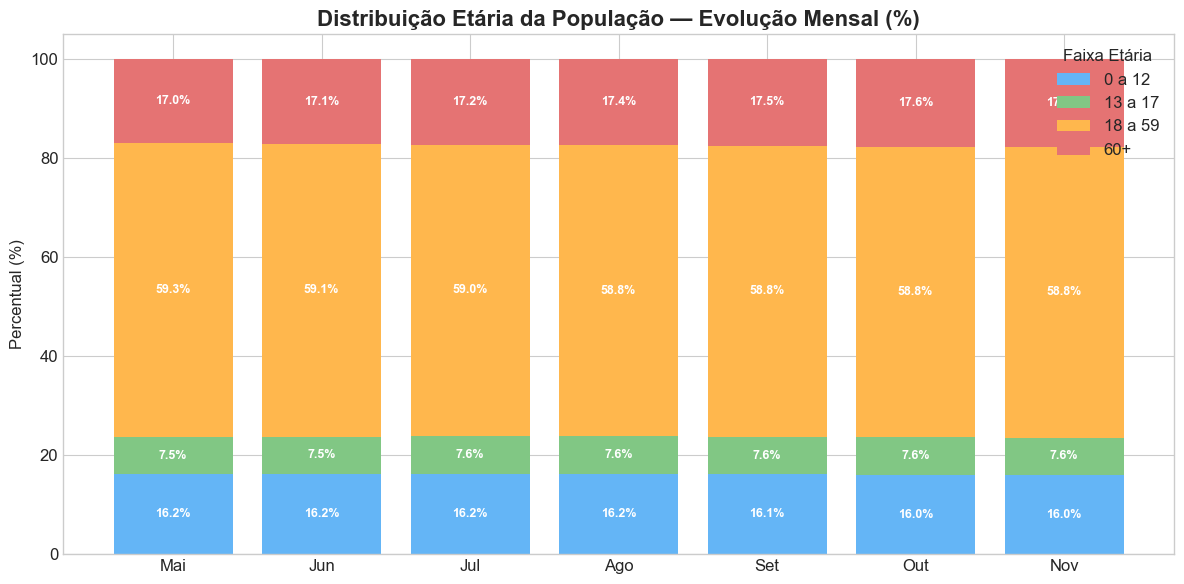

In [11]:
# Gráfico 1 — Distribuição etária por mês (barras empilhadas em %)
faixas = ['0 a 12', '13 a 17', '18 a 59', '60+']
cores_idade = ['#64B5F6', '#81C784', '#FFB74D', '#E57373']

pivot_idade = df_idade.pivot(index='mes', columns='faixa_etaria', values='percentual')[faixas]

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(MESES_LABELS))

for faixa, cor in zip(faixas, cores_idade):
    ax.bar(MESES_LABELS, pivot_idade[faixa].values, bottom=bottom, label=faixa, color=cor)
    for i, (val, b) in enumerate(zip(pivot_idade[faixa].values, bottom)):
        ax.text(i, b + val / 2, f'{val:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += pivot_idade[faixa].values

ax.set_title('Distribuição Etária da População — Evolução Mensal (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentual (%)')
ax.set_ylim(0, 105)
ax.legend(title='Faixa Etária', loc='upper right')
plt.tight_layout()
plt.show()

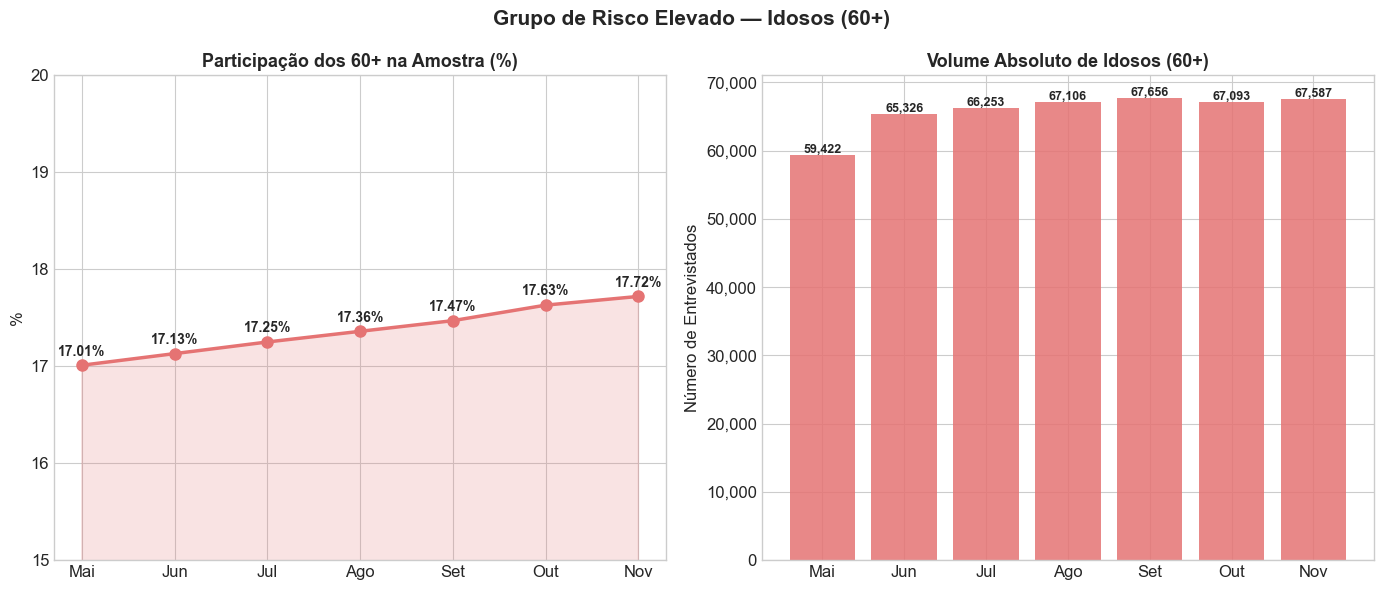

In [12]:
# Gráfico 2 — Tendência do grupo de risco elevado (60+) ao longo dos meses
df_60mais = df_idade[df_idade['faixa_etaria'] == '60+']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Percentual
ax1.plot(MESES_LABELS, df_60mais['percentual'].values, marker='o', color='#E57373', linewidth=2.5, markersize=8)
ax1.fill_between(range(len(MESES_LABELS)), df_60mais['percentual'].values, alpha=0.2, color='#E57373')
ax1.set_title('Participação dos 60+ na Amostra (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('%')
ax1.set_ylim(15, 20)
for i, v in enumerate(df_60mais['percentual'].values):
    ax1.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Volume absoluto
ax2.bar(MESES_LABELS, df_60mais['qtd'].values, color='#E57373', alpha=0.85)
ax2.set_title('Volume Absoluto de Idosos (60+)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Número de Entrevistados')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(df_60mais['qtd'].values):
    ax2.text(i, v + 300, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Grupo de Risco Elevado — Idosos (60+)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight — Faixa Etária

A faixa de **18 a 59 anos** representa cerca de **59% da população** entrevistada, sendo o principal grupo economicamente ativo — e também o principal vetor de transmissão comunitária. Os **idosos (60+)** representam em torno de **17%** da amostra, com tendência de leve crescimento ao longo dos meses, indicando progressiva inclusão desse grupo na pesquisa.

**Recomendação para preparação:**
- Estabelecer **protocolos de triagem diferenciados para idosos** como grupo de risco prioritário
- Reservar leitos de UTI considerando que a demanda de internação grave concentra-se na faixa 60+
- Criar canais de atendimento específicos (como teleatendimento) para reduzir a exposição de idosos em unidades de saúde

---
## 2. Distribuição por Sexo

Embora a COVID-19 afete ambos os sexos, estudos clínicos indicam que **homens apresentam maior risco de casos graves e mortalidade**. Analisar a composição por sexo da população entrevistada auxilia no planejamento de comunicação e de recursos hospitalares.

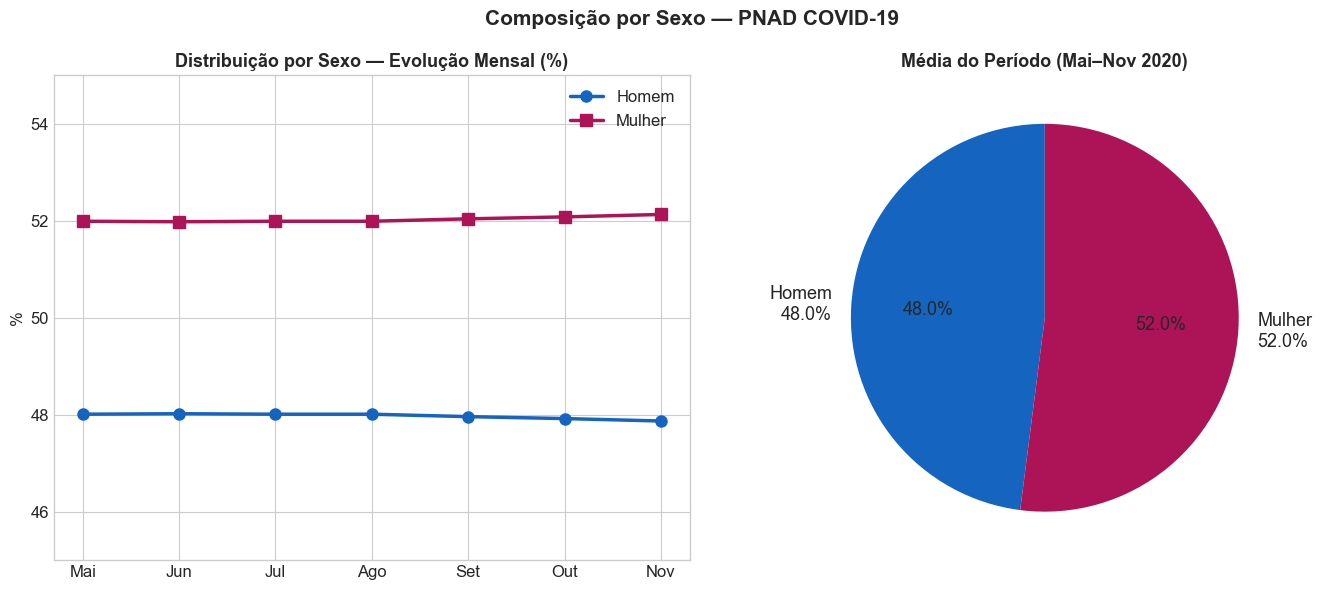

In [13]:
# Gráfico 3 — Distribuição por sexo ao longo dos meses
df_homem  = df_sexo[df_sexo['sexo'] == 'Homem'].reset_index(drop=True)
df_mulher = df_sexo[df_sexo['sexo'] == 'Mulher'].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Percentual por mês
ax1.plot(MESES_LABELS, df_homem['percentual'].values, marker='o', color='#1565C0',
         linewidth=2.5, markersize=8, label='Homem')
ax1.plot(MESES_LABELS, df_mulher['percentual'].values, marker='s', color='#AD1457',
         linewidth=2.5, markersize=8, label='Mulher')
ax1.set_title('Distribuição por Sexo — Evolução Mensal (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('%')
ax1.set_ylim(45, 55)
ax1.legend()

# Pizza com média do período
media_homem  = df_homem['percentual'].mean()
media_mulher = df_mulher['percentual'].mean()
ax2.pie(
    [media_homem, media_mulher],
    labels=[f'Homem\n{media_homem:.1f}%', f'Mulher\n{media_mulher:.1f}%'],
    colors=['#1565C0', '#AD1457'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13}
)
ax2.set_title('Média do Período (Mai–Nov 2020)', fontsize=13, fontweight='bold')

fig.suptitle('Composição por Sexo — PNAD COVID-19', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight — Sexo

A distribuição por sexo é **estável ao longo do período**, com aproximadamente **52% de mulheres** e **48% de homens**. Essa consistência indica representatividade amostral adequada.

**Recomendação para preparação:**
- Embora a amostra seja ligeiramente mais feminina, evidências clínicas indicam que **homens são mais vulneráveis a desfechos graves** — esse grupo deve receber atenção prioritária em leitos de UTI e protocolos de internação
- Estratégias de comunicação devem considerar diferentes padrões de comportamento preventivo entre os sexos

---
## 3. Nível de Escolaridade

A escolaridade é um indicador proxy de **capacidade de acesso à informação**, **compreensão de protocolos de saúde** e **renda**. Populações de baixa escolaridade tendem a ter maior dificuldade em aderir a orientações de isolamento e prevenção.

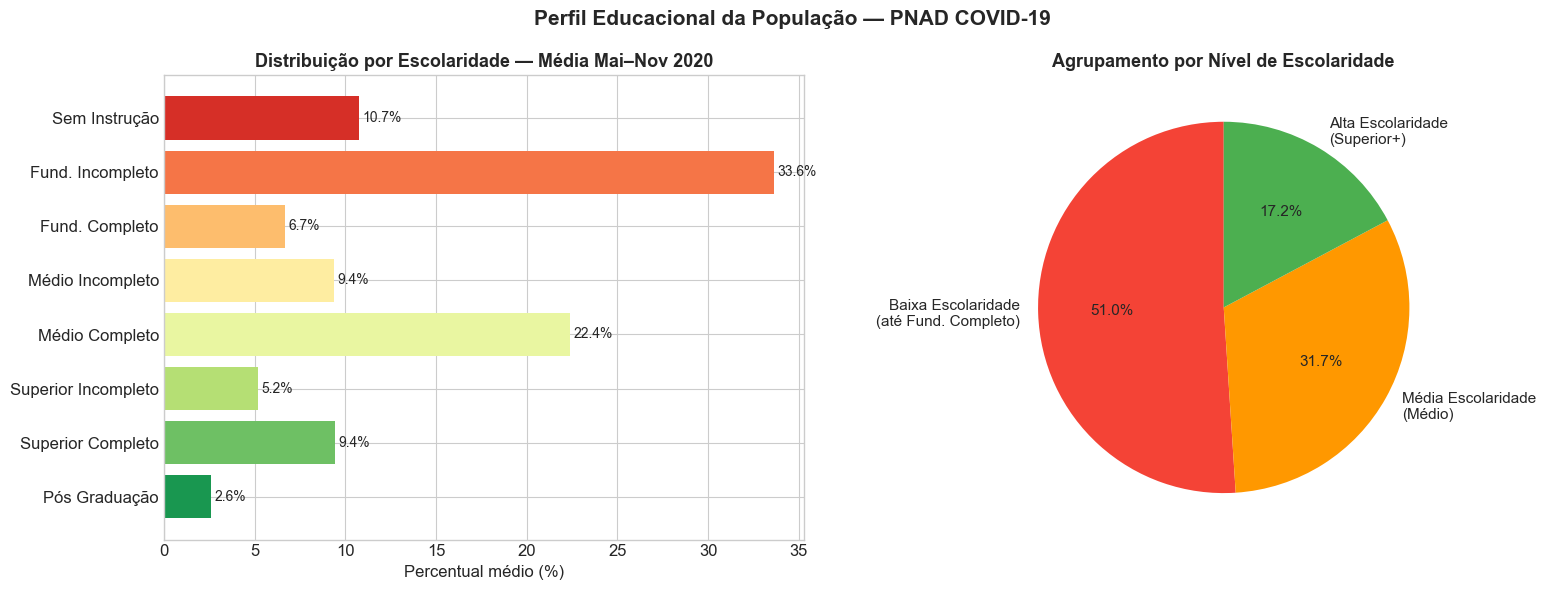

Baixa escolaridade (até Fund. Completo): 51.0%
Média escolaridade (Médio):               31.8%
Alta escolaridade (Superior+):            17.2%


In [14]:
# Gráfico 4 — Distribuição por escolaridade (média do período)
ORDEM_ESCOLAR = [
    'Sem Instrução',
    'Fundamental Incompleto',
    'Fundamental Completo',
    'Médio Incompleto',
    'Médio Completo',
    'Superior Incompleto',
    'Superior Completo',
    'Pós Graduação, Mestrado ou Doutorado'
]
LABELS_CURTOS = [
    'Sem Instrução',
    'Fund. Incompleto',
    'Fund. Completo',
    'Médio Incompleto',
    'Médio Completo',
    'Superior Incompleto',
    'Superior Completo',
    'Pós Graduação'
]

media_escol = df_escolaridade.groupby('escolaridade')['percentual'].mean().reindex(ORDEM_ESCOLAR)

# Colorir: vermelho (baixa) → verde (alta)
cores_escol = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(ORDEM_ESCOLAR)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontais
bars = ax1.barh(LABELS_CURTOS, media_escol.values, color=cores_escol)
for bar, val in zip(bars, media_escol.values):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=10)
ax1.set_title('Distribuição por Escolaridade — Média Mai–Nov 2020', fontsize=13, fontweight='bold')
ax1.set_xlabel('Percentual médio (%)')
ax1.invert_yaxis()

# Agrupamento: baixa / média / alta escolaridade
baixa  = media_escol[['Sem Instrução', 'Fundamental Incompleto', 'Fundamental Completo']].sum()
media  = media_escol[['Médio Incompleto', 'Médio Completo']].sum()
alta   = media_escol[['Superior Incompleto', 'Superior Completo',
                       'Pós Graduação, Mestrado ou Doutorado']].sum()

grupos_label = ['Baixa Escolaridade\n(até Fund. Completo)', 'Média Escolaridade\n(Médio)', 'Alta Escolaridade\n(Superior+)']
grupos_val   = [baixa, media, alta]
cores_grupo  = ['#F44336', '#FF9800', '#4CAF50']

wedges, texts, autotexts = ax2.pie(
    grupos_val, labels=grupos_label, autopct='%1.1f%%',
    colors=cores_grupo, startangle=90,
    textprops={'fontsize': 11}
)
ax2.set_title('Agrupamento por Nível de Escolaridade', fontsize=13, fontweight='bold')

fig.suptitle('Perfil Educacional da População — PNAD COVID-19', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Baixa escolaridade (até Fund. Completo): {baixa:.1f}%')
print(f'Média escolaridade (Médio):               {media:.1f}%')
print(f'Alta escolaridade (Superior+):            {alta:.1f}%')

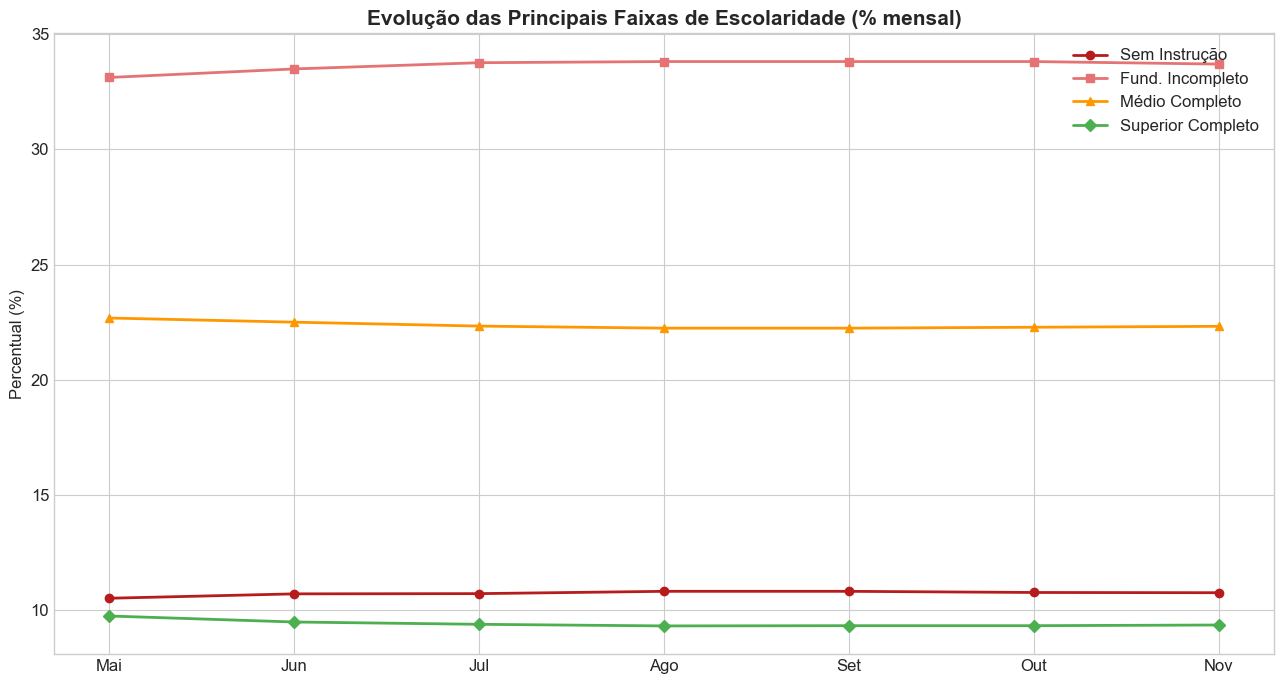

In [15]:
# Gráfico 5 — Evolução dos extremos de escolaridade ao longo dos meses
df_fund_inc  = df_escolaridade[df_escolaridade['escolaridade'] == 'Fundamental Incompleto'].reset_index(drop=True)
df_medio_comp = df_escolaridade[df_escolaridade['escolaridade'] == 'Médio Completo'].reset_index(drop=True)
df_sup_comp  = df_escolaridade[df_escolaridade['escolaridade'] == 'Superior Completo'].reset_index(drop=True)
df_sem_instr = df_escolaridade[df_escolaridade['escolaridade'] == 'Sem Instrução'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(MESES_LABELS, df_sem_instr['percentual'].values,    marker='o', linewidth=2, color='#B71C1C', label='Sem Instrução')
ax.plot(MESES_LABELS, df_fund_inc['percentual'].values,     marker='s', linewidth=2, color='#E57373', label='Fund. Incompleto')
ax.plot(MESES_LABELS, df_medio_comp['percentual'].values,   marker='^', linewidth=2, color='#FF9800', label='Médio Completo')
ax.plot(MESES_LABELS, df_sup_comp['percentual'].values,     marker='D', linewidth=2, color='#4CAF50', label='Superior Completo')

ax.set_title('Evolução das Principais Faixas de Escolaridade (% mensal)', fontsize=15, fontweight='bold')
ax.set_ylabel('Percentual (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Insight — Escolaridade

Mais de **50% da população** possui baixa escolaridade (até Ensino Fundamental completo), com destaque para o **Fundamental Incompleto (~33%)**. A distribuição é **estável ao longo dos meses**, refletindo uma característica estrutural da sociedade.

**Recomendação para preparação:**
- Materiais de comunicação em saúde devem adotar **linguagem simples e visual** (infográficos, vídeos curtos) para alcançar a maioria da população
- Unidades de saúde devem estar preparadas para **explicar protocolos de forma acessível** a pacientes com baixa escolaridade
- Estratégias digitais de conscientização alcançam principalmente a população de alta escolaridade — **canais presenciais e de rádio/TV** são mais efetivos para a maioria

---
## 4. Padrão de Restrição de Contato Social

O comportamento de isolamento social é o principal mecanismo não farmacológico de controle de pandemias. Monitorar como a população distribui seus comportamentos de contato ao longo do tempo revela:
- O **nível de adesão ao isolamento** em diferentes fases da pandemia
- A **fadiga do isolamento** — tendência de relaxamento ao longo do tempo
- O **potencial de aceleração da transmissão** conforme as restrições são afrouxadas

> *Dados disponíveis de julho a novembro de 2020.*

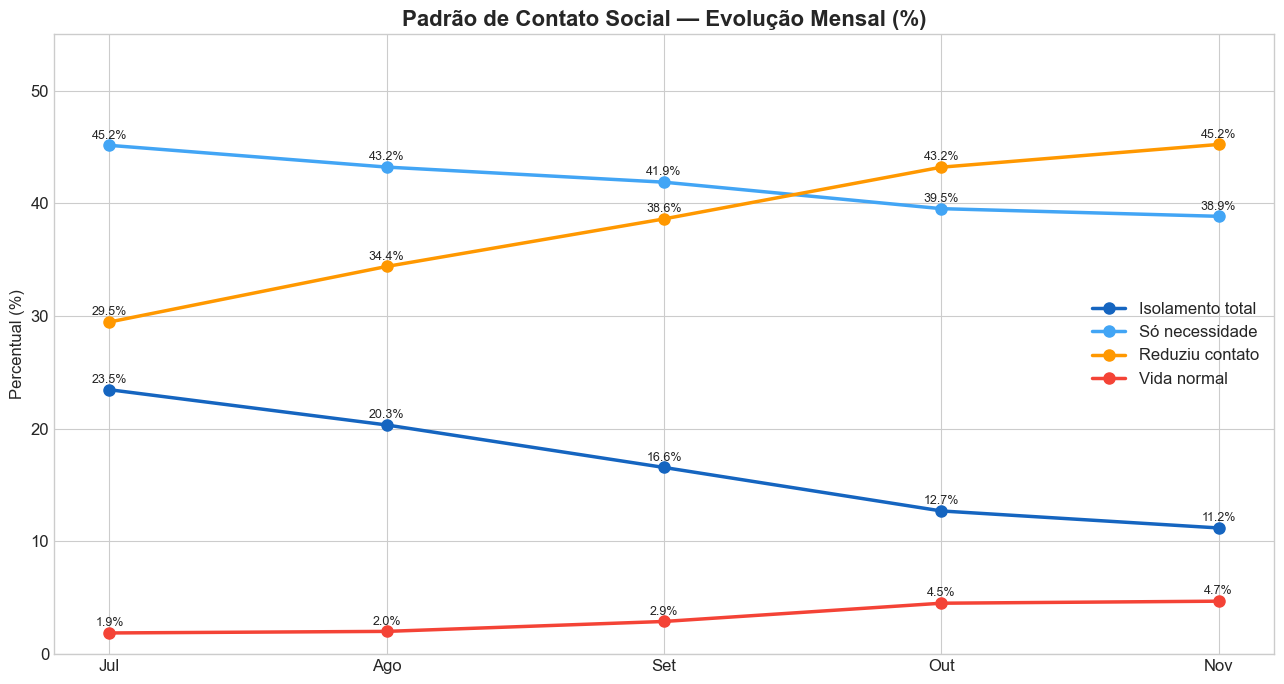

In [16]:
# Gráfico 6 — Evolução dos padrões de contato ao longo dos meses
categorias_contato = ['Isolamento total', 'Só necessidade', 'Reduziu contato', 'Vida normal']
cores_contato = {'Isolamento total': '#1565C0', 'Só necessidade': '#42A5F5',
                 'Reduziu contato': '#FF9800', 'Vida normal': '#F44336'}

pivot_contato = df_contato.pivot(index='mes', columns='contato', values='percentual')[categorias_contato]

fig, ax = plt.subplots(figsize=(13, 7))
for cat in categorias_contato:
    ax.plot(MESES_CONTATO, pivot_contato[cat].values, marker='o',
            linewidth=2.5, markersize=8, label=cat, color=cores_contato[cat])
    for i, v in enumerate(pivot_contato[cat].values):
        ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=9)

ax.set_title('Padrão de Contato Social — Evolução Mensal (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentual (%)')
ax.legend(loc='center right')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

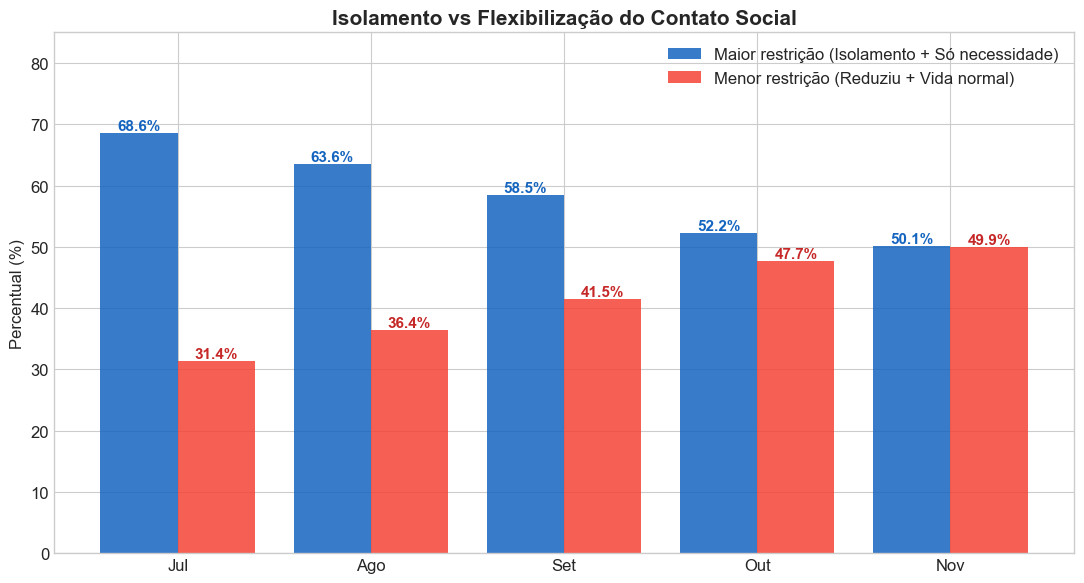

Variação do isolamento (Jul → Nov):
  Maior restrição: 68.6% → 50.1% (-18.6 p.p.)
  Menor restrição: 31.4% → 49.9% (+18.6 p.p.)


In [17]:
# Gráfico 7 — Barras empilhadas: proporção de isolamento vs flexibilização
isolamento    = pivot_contato['Isolamento total'].values + pivot_contato['Só necessidade'].values
flexibilizado = pivot_contato['Reduziu contato'].values + pivot_contato['Vida normal'].values

x = np.arange(len(MESES_CONTATO))
w = 0.4

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, isolamento,    w, label='Maior restrição (Isolamento + Só necessidade)', color='#1565C0', alpha=0.85)
b2 = ax.bar(x + w/2, flexibilizado, w, label='Menor restrição (Reduziu + Vida normal)',        color='#F44336', alpha=0.85)

for bar, val in zip(b1, isolamento):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#1565C0')
for bar, val in zip(b2, flexibilizado):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#C62828')

ax.set_xticks(x)
ax.set_xticklabels(MESES_CONTATO)
ax.set_ylabel('Percentual (%)')
ax.set_title('Isolamento vs Flexibilização do Contato Social', fontsize=15, fontweight='bold')
ax.legend()
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

print('Variação do isolamento (Jul → Nov):')
print(f'  Maior restrição: {isolamento[0]:.1f}% → {isolamento[-1]:.1f}% ({isolamento[-1]-isolamento[0]:+.1f} p.p.)')
print(f'  Menor restrição: {flexibilizado[0]:.1f}% → {flexibilizado[-1]:.1f}% ({flexibilizado[-1]-flexibilizado[0]:+.1f} p.p.)')

### Insight — Contato Social

Há uma **tendência clara de relaxamento do isolamento** entre julho e novembro de 2020:
- O grupo de **maior restrição** (isolamento total + só necessidade) caiu de ~**68%** para ~**50%**
- O grupo de **menor restrição** (reduziu contato + vida normal) cresceu de ~**31%** para ~**50%**
- A categoria "Vida normal" mais que **dobrou** (1.9% → 4.7%), indicando fadiga do isolamento

**Recomendação para preparação:**
- Planejar para a **fadiga do isolamento**: a adesão declina progressivamente com o tempo, independente da situação epidemiológica
- Utilizar monitoramento comportamental como **indicador precoce de aceleração da transmissão**
- Reservar intervenções mais restritivas para os momentos de maior gravidade, pois a população aceita restrições por tempo limitado

---
## 5. Dashboard Consolidado — Perfil Populacional

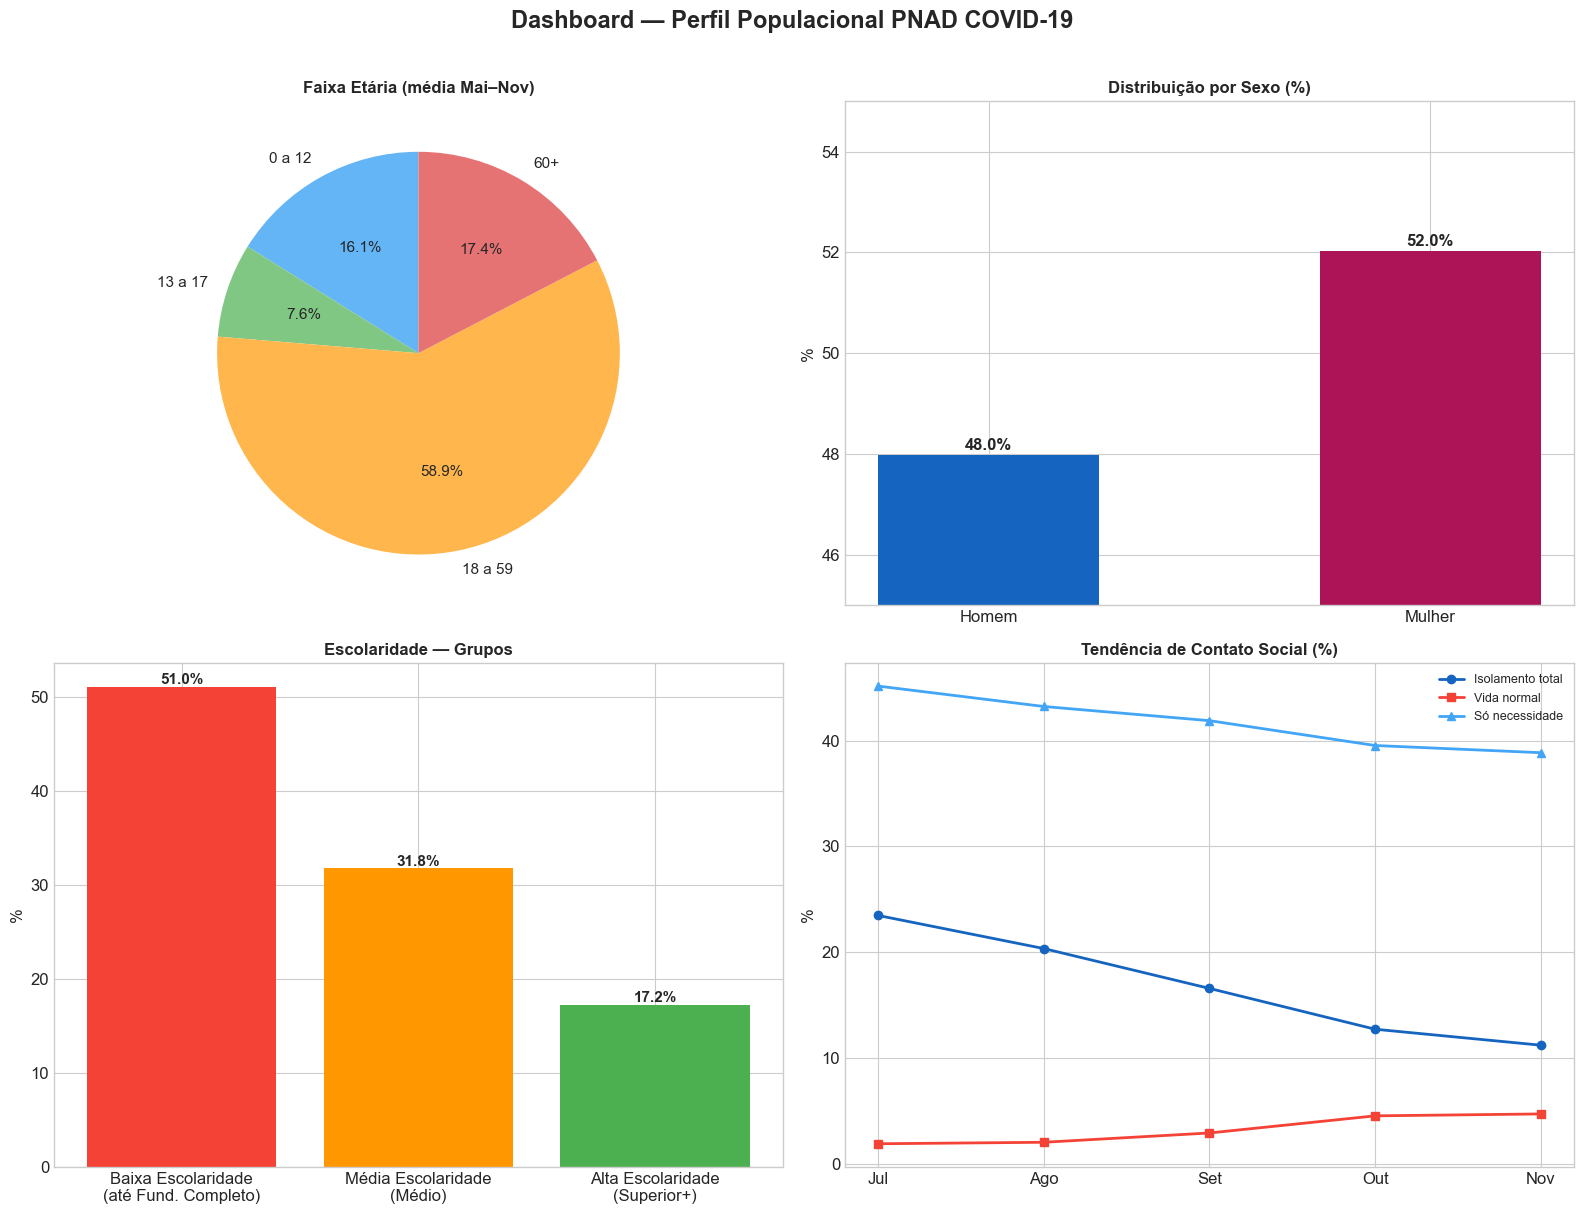

In [18]:
# Gráfico 8 — Dashboard com os 4 indicadores populacionais
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Faixa etária — média do período
ax = axes[0, 0]
media_idade = df_idade.groupby('faixa_etaria')['percentual'].mean().reindex(faixas)
wedges, texts, autotexts = ax.pie(
    media_idade.values, labels=faixas, autopct='%1.1f%%',
    colors=cores_idade, startangle=90,
    textprops={'fontsize': 11}
)
ax.set_title('Faixa Etária (média Mai–Nov)', fontweight='bold', fontsize=12)

# Top-right: Sexo
ax = axes[0, 1]
ax.bar(['Homem', 'Mulher'],
       [df_homem['percentual'].mean(), df_mulher['percentual'].mean()],
       color=['#1565C0', '#AD1457'], width=0.5)
ax.set_title('Distribuição por Sexo (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('%')
ax.set_ylim(45, 55)
for i, v in enumerate([df_homem['percentual'].mean(), df_mulher['percentual'].mean()]):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Bottom-left: Escolaridade — agrupada
ax = axes[1, 0]
ax.bar(grupos_label, grupos_val, color=cores_grupo)
ax.set_title('Escolaridade — Grupos', fontweight='bold', fontsize=12)
ax.set_ylabel('%')
for i, v in enumerate(grupos_val):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Bottom-right: Contato social — tendência de isolamento
ax = axes[1, 1]
ax.plot(MESES_CONTATO, pivot_contato['Isolamento total'].values, marker='o', color='#1565C0',
        linewidth=2, label='Isolamento total')
ax.plot(MESES_CONTATO, pivot_contato['Vida normal'].values, marker='s', color='#F44336',
        linewidth=2, label='Vida normal')
ax.plot(MESES_CONTATO, pivot_contato['Só necessidade'].values, marker='^', color='#42A5F5',
        linewidth=2, label='Só necessidade')
ax.set_title('Tendência de Contato Social (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('%')
ax.legend(fontsize=9)

fig.suptitle('Dashboard — Perfil Populacional PNAD COVID-19', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Conclusão — Plano Demográfico para Preparação Pandêmica

A análise do perfil populacional da PNAD COVID-19 revela **quatro dimensões estruturais** que devem orientar o planejamento estratégico de hospitais e gestores de saúde pública:

### 1. Gestão do Risco por Faixa Etária
- Os **idosos (60+)** representam ~17% da população e são o principal grupo de risco para internação e mortalidade
- A faixa de **18-59 anos (~59%)** é a principal transmissora — prioridade em campanhas de prevenção
- **Ação:** Separar fisicamente atendimentos de idosos (consultas, vacinação) para evitar exposição cruzada

### 2. Comunicação Inclusiva por Gênero
- A distribuição é equilibrada (~52% mulheres), mas **homens apresentam maior risco de desfechos graves**
- **Ação:** Criar campanhas específicas para engajar homens em comportamentos preventivos, já que tendem a buscar menos atendimento precoce

### 3. Comunicação Acessível para Baixa Escolaridade
- Mais de **50% da população tem baixa escolaridade** — a maioria da população não compreende comunicados técnicos
- **Ação:** Investir em materiais visuais, linguagem simples e canais de massa (TV, rádio, agentes comunitários de saúde)

### 4. Planejamento para a Fadiga do Isolamento
- O comportamento de isolamento **declina de forma consistente** com o tempo — de ~68% em julho para ~50% em novembro
- **Ação:** Monitorar indicadores de mobilidade e contato social como **sinais de alerta epidemiológico**; não depender de isolamento prolongado como única estratégia de controle

---
*Estudo desenvolvido com dados da PNAD COVID-19 (IBGE) — Projeto FIAP*